# Évaluation des Modèles

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.prophet import ProphetRegressor
from src.models.baselines import \
    AverageRegressor, LastWeekRegressor, YesterdayRegressor, LinearRegressor, SimilarDayRegressor
from src.models.xgboost.xgboost_regressor import XGBoostRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

Importing plotly failed. Interactive plots will not work.


In [2]:
evaluator = TimeSeriesEvaluator(df, "perfect")

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start, load_existing_splits=True)


Vérification de la table de features
Lignes totales : 85441
Jours de prévision uniques : 3561
Cibles manquantes : 0

ATTENTION : Jours avec un nombre d'horizons anormal (!= 23, 24, 25) :
prevision_date
2026-09-30 00:00:00+02:00    2
dtype: int64
Découpage Temporel
Train: 61344 lignes (71.8%)
Val: 8784 lignes (10.3%)
Test: 15313 lignes (17.9%)



## 3. Modèles de Références

In [3]:
evaluator.grid_search_rolling_validation(AverageRegressor, [{}])

evaluator.grid_search_rolling_validation(LastWeekRegressor, [{}])

evaluator.grid_search_rolling_validation(YesterdayRegressor, [{}])

evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    {
		"k": [4],
		"temp_weight": [100.0, 1000.0]
	}
)

evaluator.grid_search_rolling_validation(
    LinearRegressor,
    [{"features_cols": [
        [
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
	]
    ]}]
);

Grid Search de AverageRegressor :

Combination 1/1 : {}
Évaluation de AverageRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 9472.67 MW |RMSE = 11667.64 MW |MAPE = 18.67%


Validation : MAE = 8503.59 MW |RMSE = 10297.54 MW |MAPE = 18.26%

Best MAE sur Validation : 8503.59 MW
Best Params : {}

Grid Search de LastWeekRegressor :

Combination 1/1 : {}
Évaluation de LastWeekRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 3603.55 MW |RMSE = 5263.36 MW |MAPE = 6.51%


Validation : MAE = 3229.23 MW |RMSE = 4845.62 MW |MAPE = 6.05%

Best MAE sur Validation : 3229.23 MW
Best Params : {}

Grid Search de YesterdayRegressor :

Combination 1/1 : {}
Évaluation de YesterdayRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 2825.03 MW |RMSE = 4156.50 MW |MAPE = 5.45%


Validation : MAE = 2530.85 MW |RMSE = 3662.52 MW |MAPE = 5.10%

## 4. Linear Regression

In [4]:
evaluator.grid_search_rolling_validation(
    LinearRegressor,
    [{"features_cols": [
        [
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
		'temperature_c_pondere_pop_meme_heure_derniere_connue',
		'temperature_c_pondere_pop_derniere_connue',
		'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'
	]
    ]}]
);

Grid Search de LinearRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances', 'temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366']}
Évaluation de LinearRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 0.00 MW |RMSE = 0.00 MW |MAPE = 0.00%


Validation : MAE = 0.00 MW |RMSE = 0.00 MW |MAPE = 0.00%

Best MAE sur Validation : 0.00 MW
Best Params : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'heure', 'jour_semaine', 'jour_annee'

## 5. Prophet

In [5]:
evaluator.grid_search_rolling_validation(
    ProphetRegressor,
    [{"features_cols": [
        ["temperature_c_pondere_pop_sous_15_derniere_connue", "temperature_c_pondere_pop_au_dessus_22_derniere_connue"]
    ]}]
)

Grid Search de ProphetRegressor :

Combination 1/1 : {'features_cols': ['temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue']}
Évaluation de ProphetRegressor | 8784 lignes | réentraînement/6ME | 3 itérations


17:31:01 - cmdstanpy - INFO - Chain [1] start processing
17:31:28 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-01 00:00...

17:31:37 - cmdstanpy - INFO - Chain [1] start processing
17:32:21 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-31 00:00...

17:32:30 - cmdstanpy - INFO - Chain [1] start processing
17:32:54 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-07-31 00:00...
Train : MAE = 153907.64 MW |RMSE = 280775.26 MW |MAPE = 300.22%


Validation : MAE = 28477.48 MW |RMSE = 40815.55 MW |MAPE = 62.92%

Best MAE sur Validation : 28477.48 MW
Best Params : {'features_cols': ['temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue']}



[{'train_metrics': {'MAE': 153907.6396344304,
   'RMSE': 280775.2574341998,
   'MAPE': 300.2246688209924,
   'per_hour':                        MAE           RMSE
   cible_heure                              
   0            153756.940254  281189.243783
   1            153950.261904  280920.937650
   2            153946.275714  280641.569553
   3            154121.413650  280639.484955
   4            154079.772540  280653.820819
   5            154089.729403  280613.336939
   6            153960.696303  280704.501120
   7            154026.450701  280755.883677
   8            153969.634155  280807.648933
   9            153923.334200  280795.380065
   10           153923.435354  280800.463292
   11           153769.548711  280865.207454
   12           153851.385939  280801.430165
   13           153697.897070  280933.828618
   14           153772.731003  280870.620764
   15           153889.438649  280757.256501
   16           153905.805552  280709.455546
   17           153850.0766

## 6. XGB

In [6]:
evaluator.grid_search_rolling_validation(
    XGBoostRegressor,
    [{}]
);

Grid Search de XGBoostRegressorCustom :

Combination 1/1 : {}
Évaluation de XGBoostRegressorCustom | 8784 lignes | réentraînement/6ME | 3 itérations

Nombre d'arbres réellement retenus (best_iteration) : 2982 / 3000
Meilleure MAE validation : 61.58
Progression: 2024-01-01 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 2997 / 3000
Meilleure MAE validation : 99.75
Progression: 2024-01-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 3000 / 3000
Meilleure MAE validation : 44.16
Progression: 2024-07-31 00:00...
Train : MAE = 53.31 MW |RMSE = 82.98 MW |MAPE = 0.10%


Validation : MAE = 58.56 MW |RMSE = 82.29 MW |MAPE = 0.12%

Best MAE sur Validation : 58.56 MW
Best Params : {}



## Visualisation

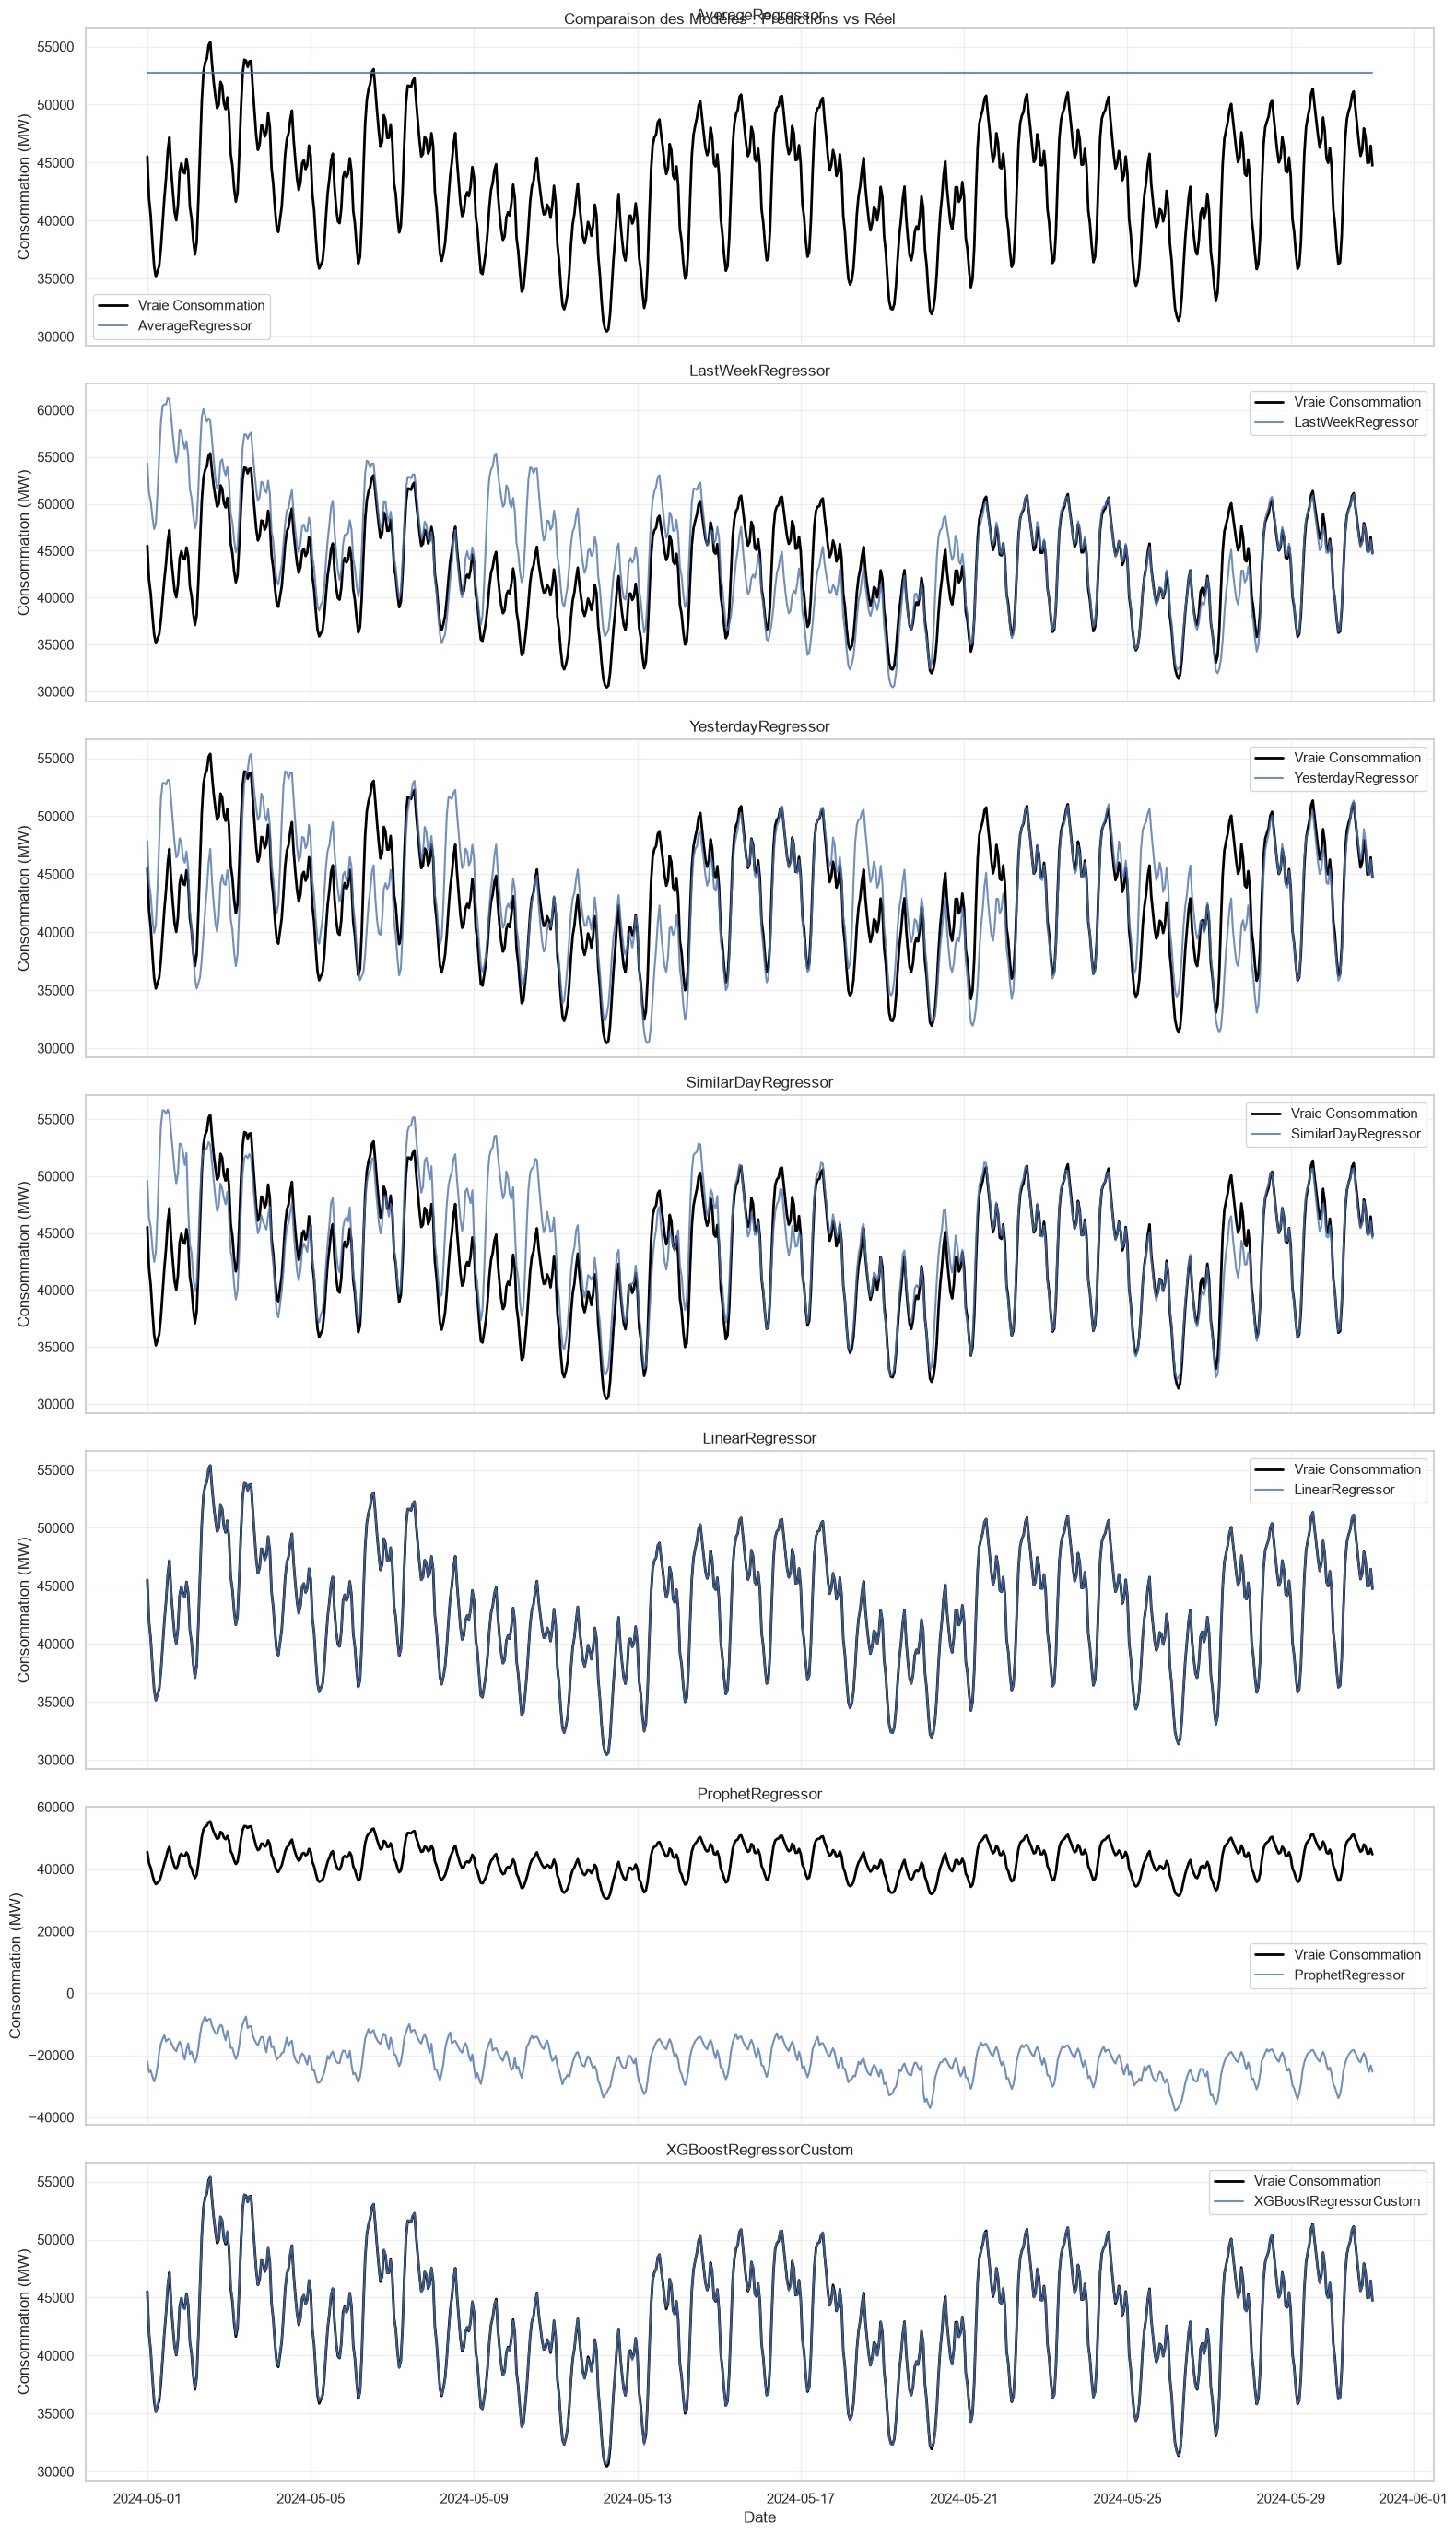

In [7]:
# Zoomons sur le mois de Mai 2024
start_zoom = pd.to_datetime('2024-05-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-05-31').tz_localize('Europe/Paris')

evaluator.plot_predictions(use_test=False, start_date=start_zoom, end_date=end_zoom)

In [8]:
evaluator.plot_feature_importances(top_n=15)

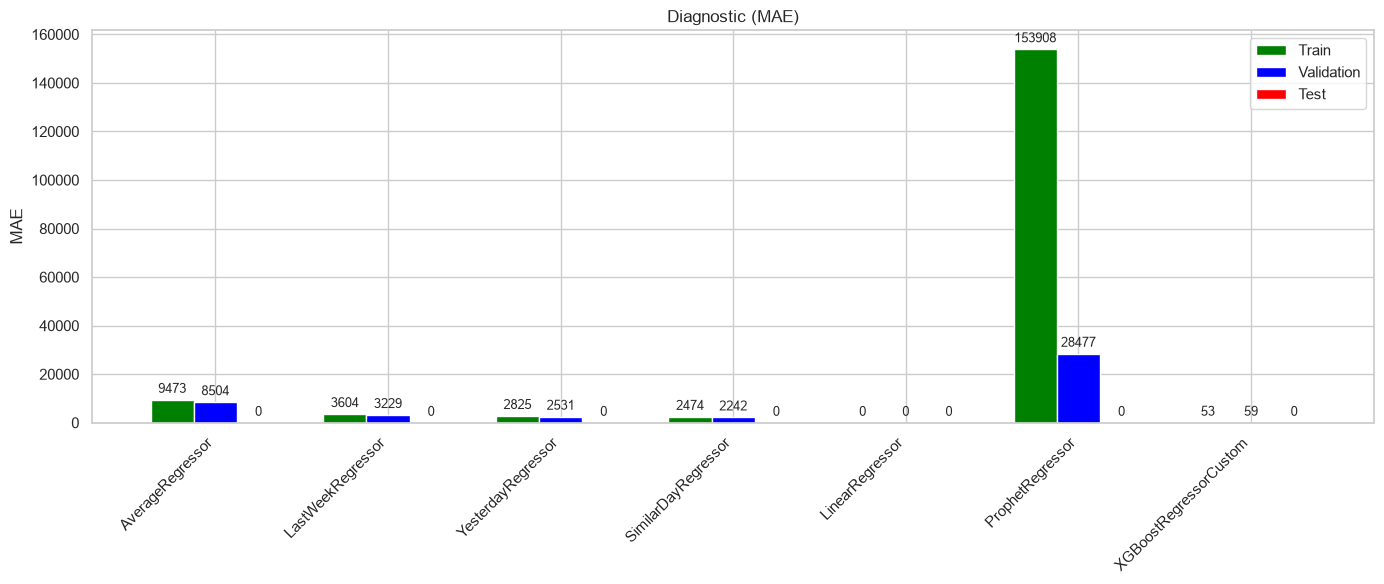

In [9]:
evaluator.plot_train_val_test_metrics()

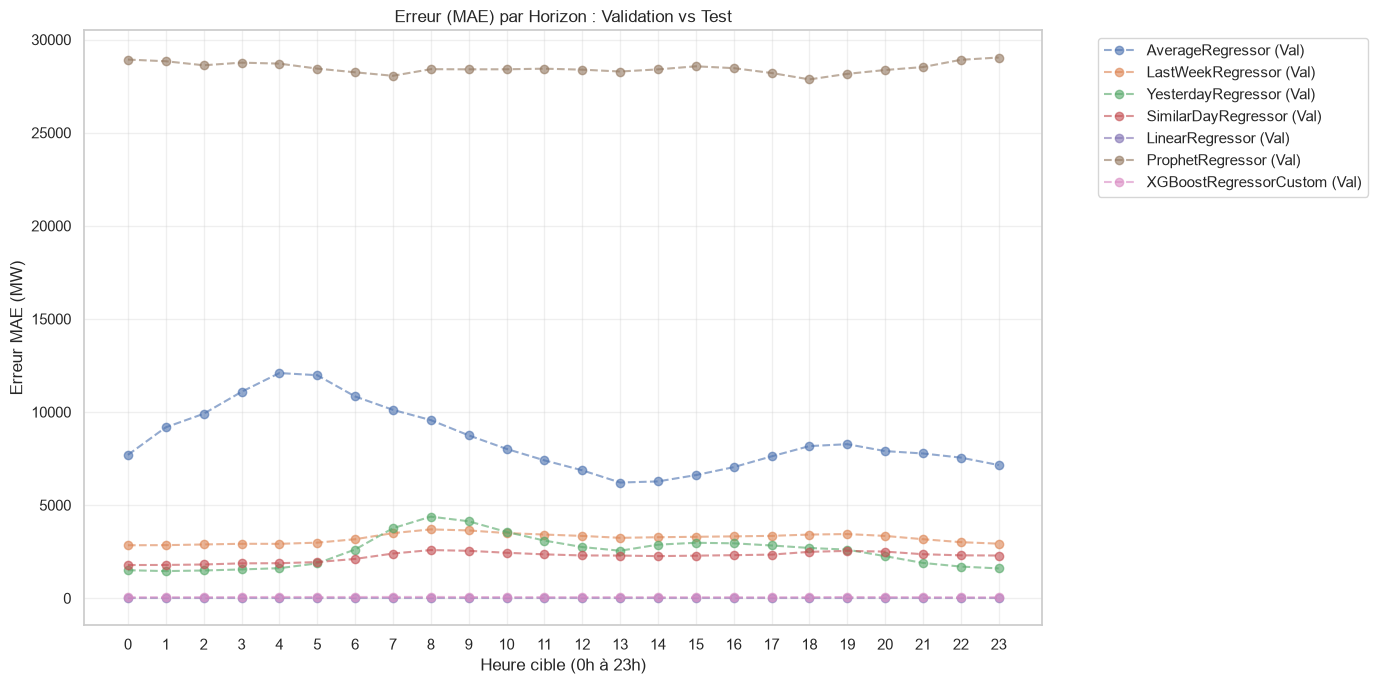

In [10]:
evaluator.plot_error_per_horizon()